In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("feature_engineered_dataset.csv")

In [3]:
#EDA is the process of analyzing a dataset to understand its structure, patterns, and relationships before applying machine learning or building models.

In [4]:
print(df.shape)      # rows, columns
print(df.info())     # datatypes
print(df.describe()) # statistics

(73100, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                73100 non-null  object 
 1   store_id            73100 non-null  object 
 2   product_id          73100 non-null  object 
 3   category            73100 non-null  object 
 4   region              73100 non-null  object 
 5   inventory_level     73100 non-null  int64  
 6   units_sold          73100 non-null  int64  
 7   units_ordered       73100 non-null  int64  
 8   demand_forecast     73100 non-null  float64
 9   price               73100 non-null  float64
 10  discount            73100 non-null  float64
 11  weather_condition   73100 non-null  object 
 12  holiday_promotion   73100 non-null  int64  
 13  competitor_pricing  73100 non-null  float64
 14  seasonality         73100 non-null  object 
 15  visitors            73100 non-null  int64

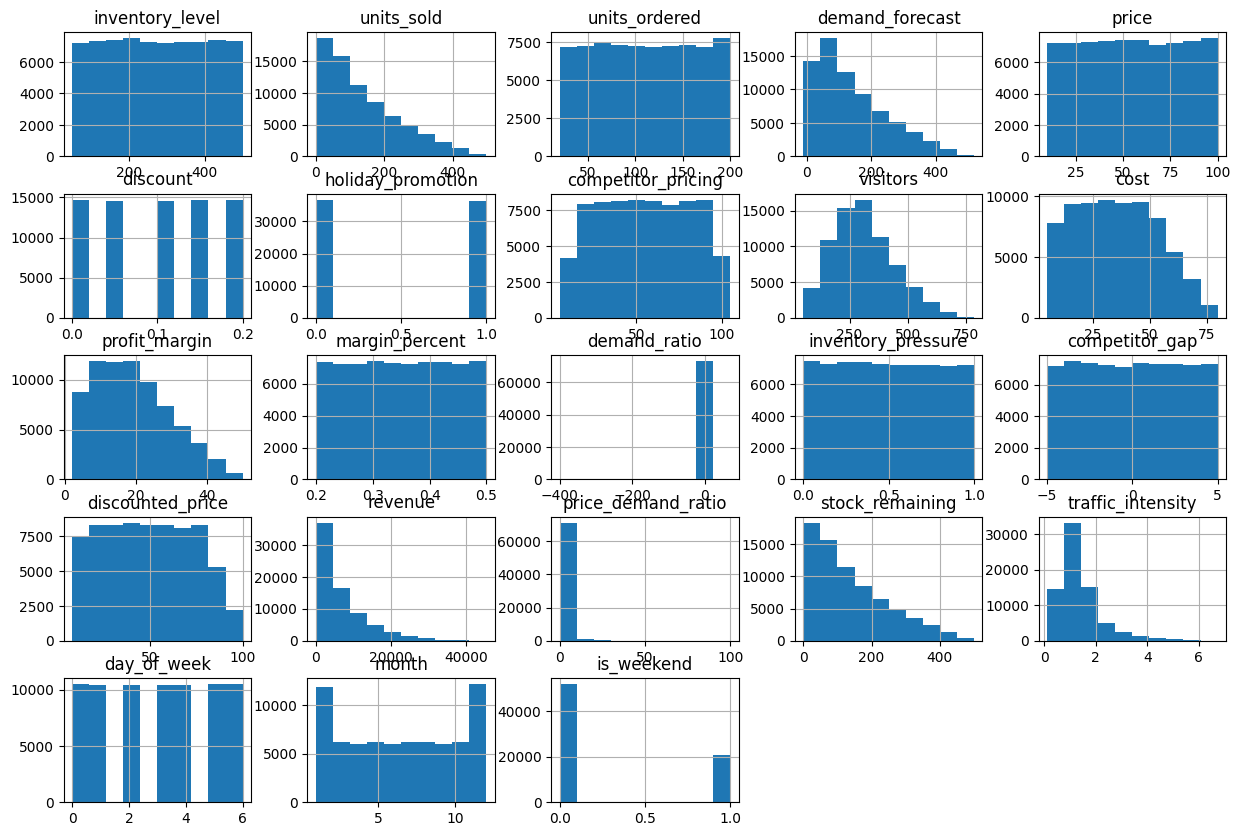

In [5]:
# Check distributions of numerical values to understand spread and skewness. 
#If right-skewed → most values are small, few large
#If normal → good for ML models
df.hist(figsize=(15,10))
plt.show()

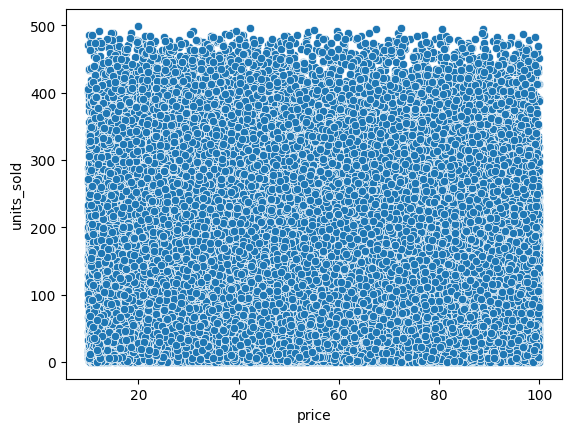

In [9]:
#Understand relationship between price and demand.
sns.scatterplot(x="price", y="units_sold", data=df)
plt.show()

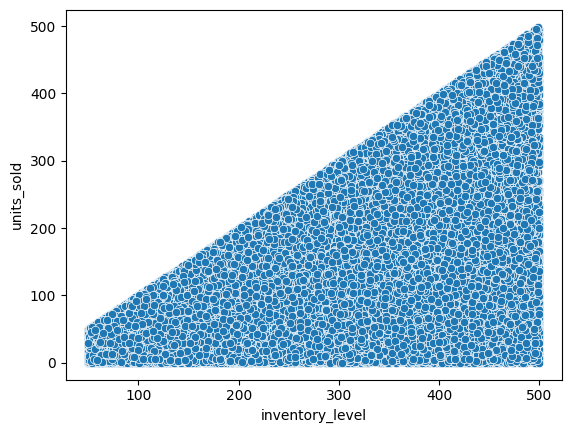

In [11]:
#Inventory vs Sales
sns.scatterplot(x="inventory_level", y="units_sold", data=df)
plt.show()

#As inventory increases → units_sold also increases . There is a strong positive relationship

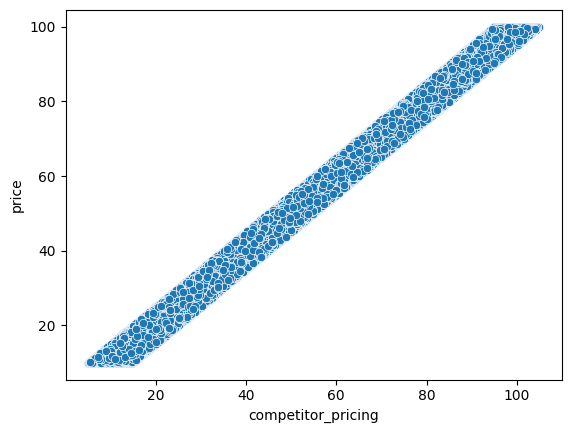

In [12]:
#Compare competitor pricing with your price.
sns.scatterplot(x="competitor_pricing", y="price", data=df)
plt.show()

#As competitor price increases → our price also increases

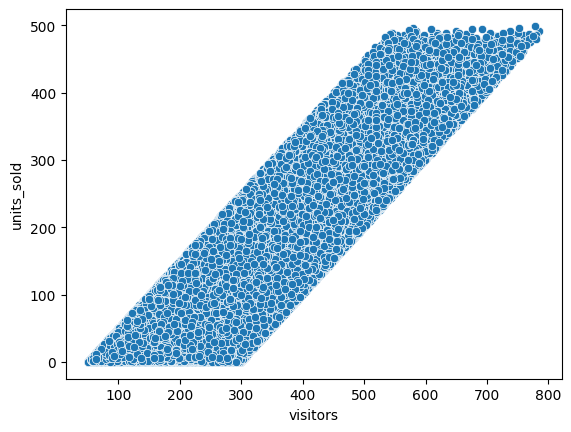

In [13]:
#Visitors vs Sales. Analyze conversion behavior.
sns.scatterplot(x="visitors", y="units_sold", data=df)
plt.show()

# Strong positive relationship, consistent conversion rate

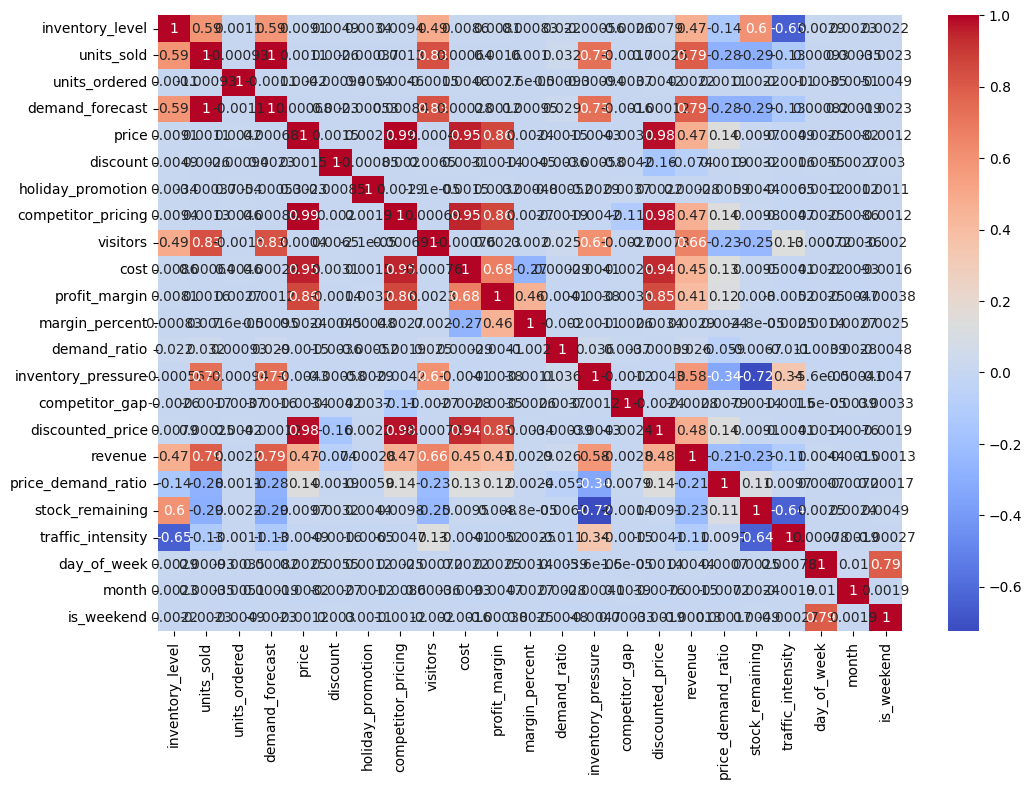

In [14]:
#Identify relationships between all numeric variables.
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

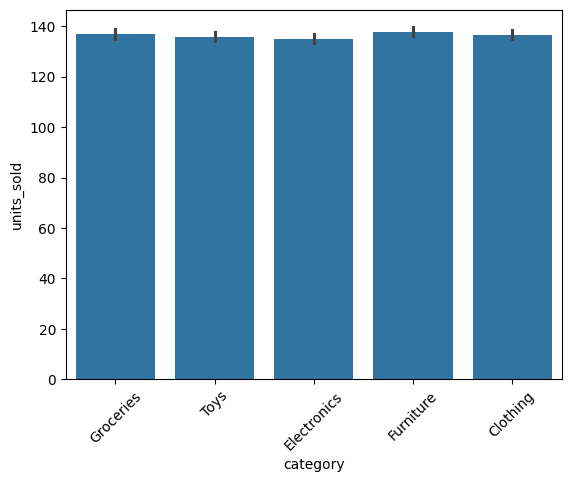

In [15]:
#Understand which categories sell more.
sns.barplot(x="category", y="units_sold", data=df)
plt.xticks(rotation=45)
plt.show()

#units sold are nearly equal across all product categories. No single category dominates, and low variation suggests consistent performance across categories.

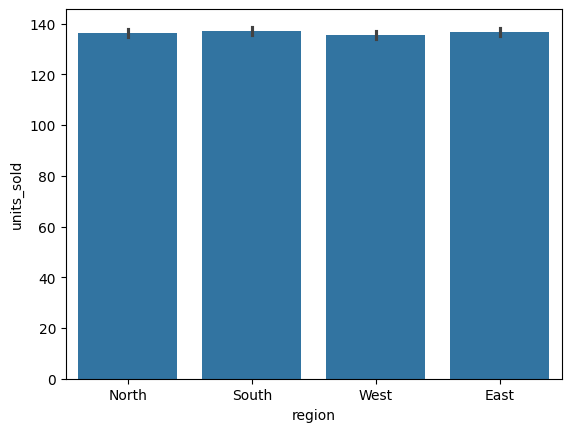

In [16]:
#Region Wise analysis
sns.barplot(x="region", y="units_sold", data=df)
plt.show()

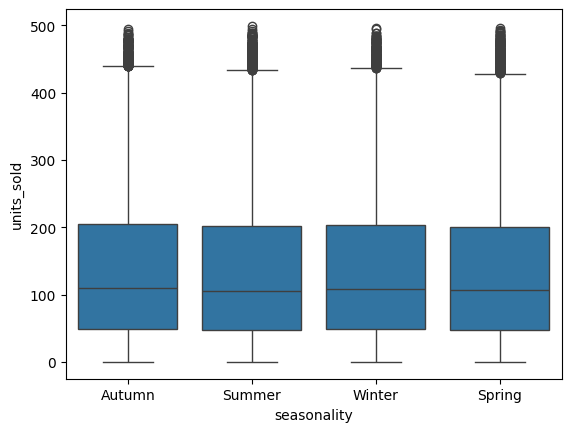

In [17]:
#Analyze how seasons affect demand.
sns.boxplot(x="seasonality", y="units_sold", data=df)
plt.show()

#units sold are consistent across all seasons, with similar median values and spread. 
#This indicates that seasonality has minimal impact on demand, although occasional high-value outliers suggest temporary sales spikes.

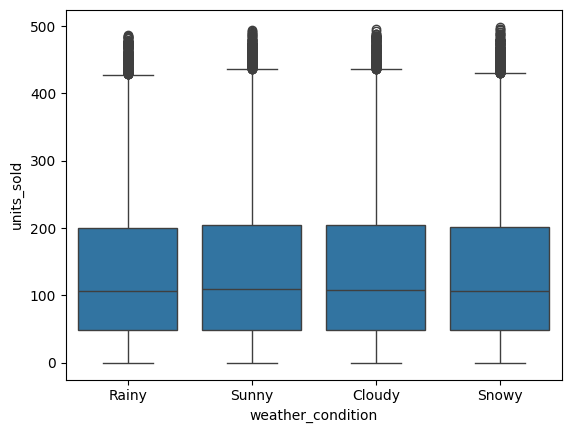

In [18]:
#Check how weather conditions affect demand.
sns.boxplot(x="weather_condition", y="units_sold", data=df)
plt.show()

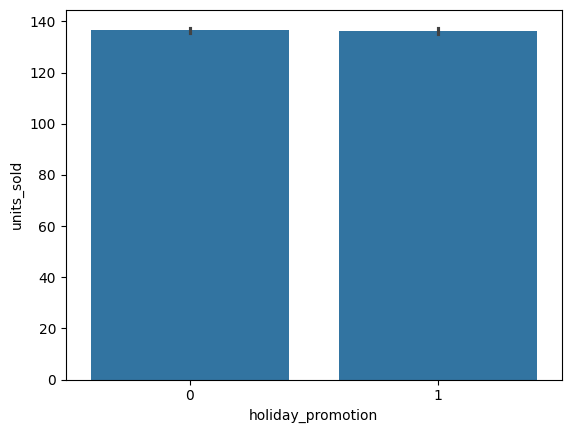

In [19]:
#Check impact of holidays and promotions.
sns.barplot(x="holiday_promotion", y="units_sold", data=df)
plt.show()

#Sales during normal days and holidays/promotions are nearly the same

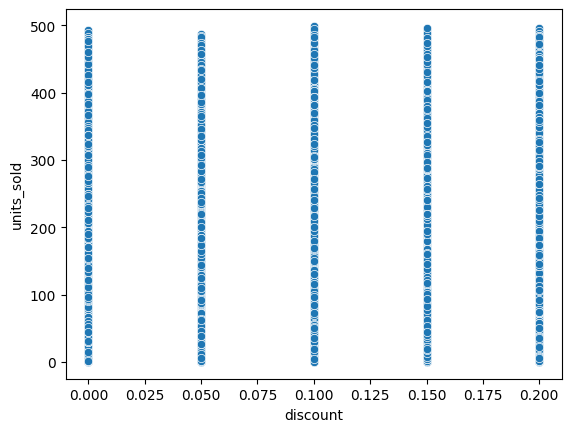

In [20]:
#Analyze how discounts affect sales.
sns.scatterplot(x="discount", y="units_sold", data=df)
plt.show()

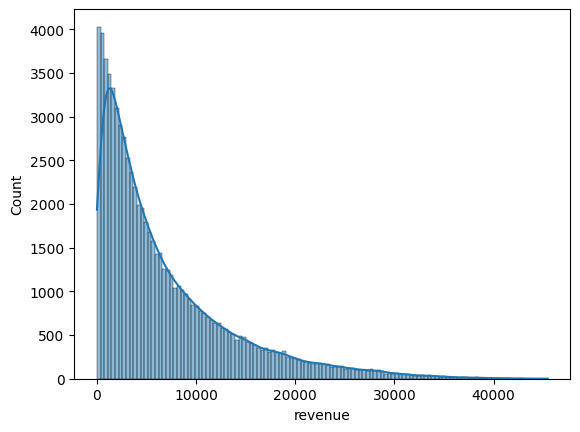

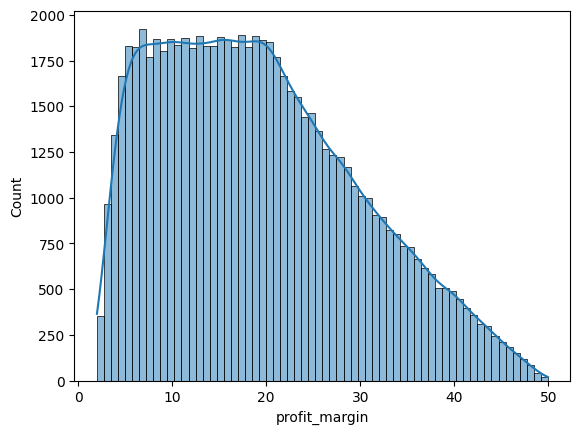

In [21]:
#Understand revenue distribution. And profit margin analysis
sns.histplot(df["revenue"], kde=True)
plt.show()

sns.histplot(df["profit_margin"], kde=True)
plt.show()

#Revenue is highly variable with extreme values (outliers).
#Profit margin is more stable, concentrated in a narrower range.

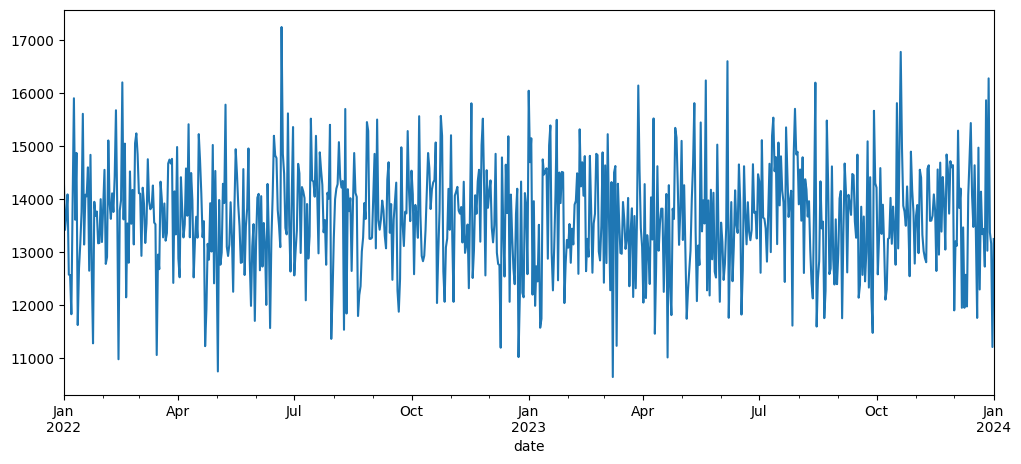

In [22]:
df["date"] = pd.to_datetime(df["date"])

df.groupby("date")["units_sold"].sum().plot(figsize=(12,5))
plt.show()

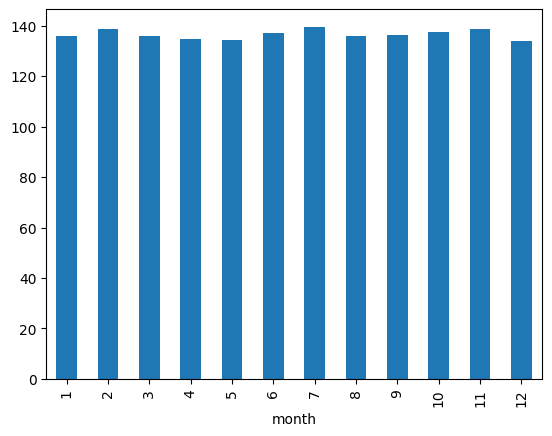

In [23]:
df.groupby("month")["units_sold"].mean().plot(kind="bar")
plt.show()

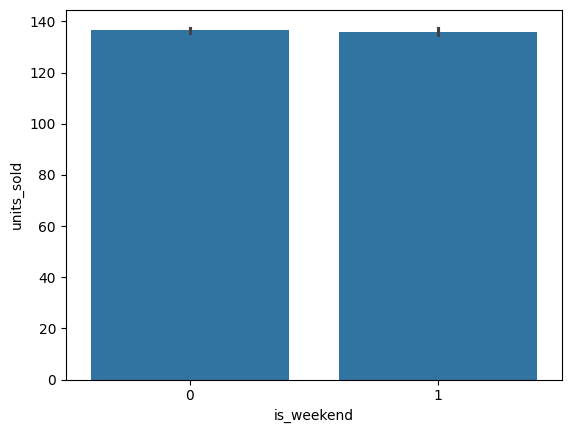

In [24]:
sns.barplot(x="is_weekend", y="units_sold", data=df)
plt.show()

In [26]:
print(df.columns)
df["conversion_rate"] = df["units_sold"] / df["visitors"]

Index(['date', 'store_id', 'product_id', 'category', 'region',
       'inventory_level', 'units_sold', 'units_ordered', 'demand_forecast',
       'price', 'discount', 'weather_condition', 'holiday_promotion',
       'competitor_pricing', 'seasonality', 'visitors', 'cost',
       'profit_margin', 'margin_percent', 'demand_ratio', 'inventory_pressure',
       'competitor_gap', 'discounted_price', 'revenue', 'price_demand_ratio',
       'stock_remaining', 'traffic_intensity', 'day_of_week', 'month',
       'is_weekend', 'price_bin'],
      dtype='object')


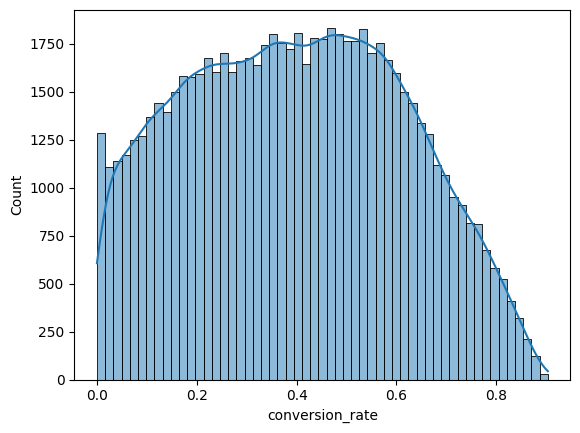

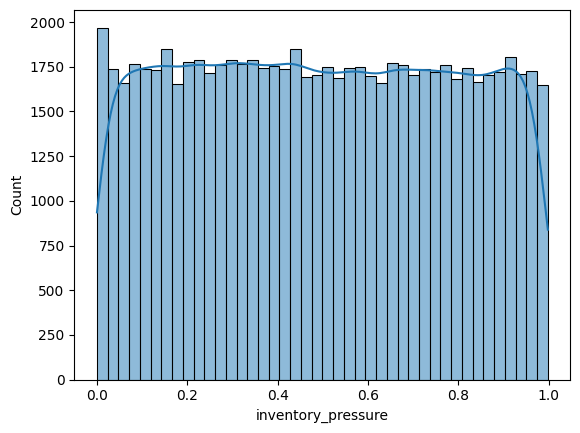

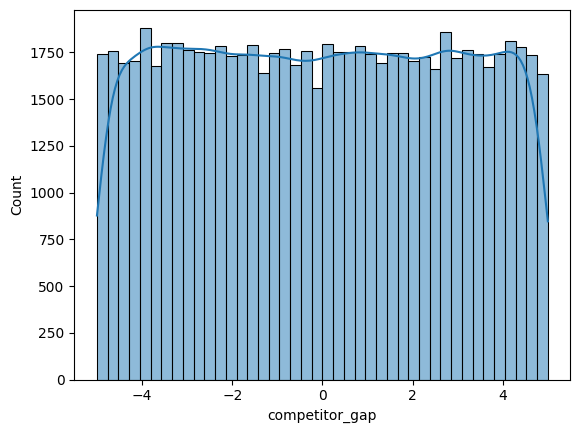

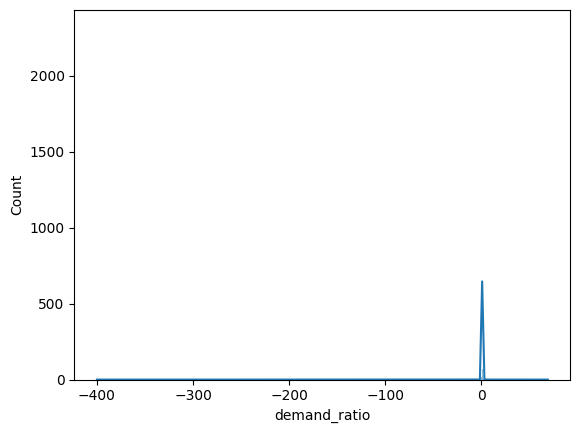

In [27]:
sns.histplot(df["conversion_rate"], kde=True)
plt.show()

sns.histplot(df["inventory_pressure"], kde=True)
plt.show()

sns.histplot(df["competitor_gap"], kde=True)
plt.show()

sns.histplot(df["demand_ratio"], kde=True)
plt.show()